# Storyboard Agent Graph Debug

노드별 상태 업데이트를 단계별로 출력하는 디버그 노트북입니다.

In [1]:
import os
import sys
from pathlib import Path
from dotenv import load_dotenv, dotenv_values
from langchain_teddynote import logging

def find_project_root(start: Path) -> Path:
    """현재 위치에서 위로 올라가며 src/graph.py와 .env가 있는 루트를 찾는다."""
    candidates = [start, *start.parents]
    for base in candidates:
        direct = base
        nested = base / "backend" / "storyboard-agent"
        for cand in (direct, nested):
            if (cand / "src" / "graph.py").exists() and (cand / ".env").exists():
                return cand
    raise RuntimeError("storyboard-agent 프로젝트 루트를 찾지 못했습니다.")

PROJECT_ROOT = find_project_root(Path.cwd())
ENV_PATH = PROJECT_ROOT / ".env"

sys.path.insert(0, str(PROJECT_ROOT / "src"))

# 03 노트북과 동일하게: 기존 환경변수 우선, .env는 비어있을 때만 보충
before_key = os.getenv("OPENAI_API_KEY", "")
load_dotenv(ENV_PATH, override=False)
after_key = os.getenv("OPENAI_API_KEY", "")

logging.langsmith("tzudong-agent")

dotenv_key = dotenv_values(ENV_PATH).get("OPENAI_API_KEY", "")
print(f"cwd={Path.cwd()}")
print(f"✅ 프로젝트 루트: {PROJECT_ROOT}")
print(f"✅ .env 경로: {ENV_PATH} (exists={ENV_PATH.exists()})")
print(f"✅ 기존 환경변수 OPENAI_API_KEY: {'있음' if before_key else '없음'}")
print(f"✅ .env OPENAI_API_KEY: {'있음' if dotenv_key else '없음'}")
print(f"✅ 최종 사용 OPENAI_API_KEY: {'설정됨' if after_key else '미설정'}")

if after_key:
    source = "env" if before_key else ".env"
    print(f"   source={source}, prefix={after_key[:7]}..., len={len(after_key)}")
else:
    raise RuntimeError("OPENAI_API_KEY가 로드되지 않았습니다. 환경변수 또는 .env를 확인하세요.")



LangSmith 추적을 시작합니다.
[프로젝트명]
tzudong-agent
cwd=/Users/byeon-ujung/Desktop/programming/tzudong_pjt/tzudong/backend/storyboard-agent/scripts
✅ 프로젝트 루트: /Users/byeon-ujung/Desktop/programming/tzudong_pjt/tzudong/backend/storyboard-agent
✅ .env 경로: /Users/byeon-ujung/Desktop/programming/tzudong_pjt/tzudong/backend/storyboard-agent/.env (exists=True)
✅ 기존 환경변수 OPENAI_API_KEY: 없음
✅ .env OPENAI_API_KEY: 있음
✅ 최종 사용 OPENAI_API_KEY: 설정됨
   source=.env, prefix=sk-proj..., len=164


In [2]:
import importlib
import prompts.feedback
import agents.designer

importlib.reload(prompts.feedback)
importlib.reload(agents.designer)

from graph import build_graph
graph = build_graph()
print("graph compiled")


/opt/anaconda3/envs/tzudong/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


graph compiled


```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	extract_slots(extract_slots)
	supervisor(supervisor)
	researcher(researcher)
	intern(intern)
	designer(designer)
	__end__([<p>__end__</p>]):::last
	__start__ --> extract_slots;
	designer -. &nbsp;end&nbsp; .-> __end__;
	designer -.-> supervisor;
	extract_slots --> supervisor;
	intern --> researcher;
	researcher -.-> intern;
	researcher -.-> supervisor;
	supervisor -.-> designer;
	supervisor -.-> researcher;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

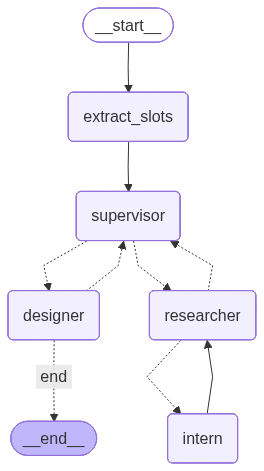

In [3]:
from IPython.display import Markdown, Image, display

graph_xray = graph.get_graph(xray=True)
mermaid = graph_xray.draw_mermaid()
display(Markdown(f"```mermaid\n{mermaid}\n```"))

png = graph_xray.draw_mermaid_png()
display(Image(data=png))

In [4]:
from typing import Any
import uuid

from langchain_core.messages import AIMessage, HumanMessage, ToolMessage
from langgraph.types import Command


def _short(value: Any, limit: int = 240) -> str:
    text = str(value).replace("\n", " ")
    return text if len(text) <= limit else text[:limit] + "..."


def _summarize_modified(modified: dict, limit: int = 8) -> str:
    if not isinstance(modified, dict) or not modified:
        return "{}"
    items = []
    for i, (k, v) in enumerate(modified.items()):
        if i >= limit:
            items.append("...")
            break
        status = v.get("status") if isinstance(v, dict) else None
        version = v.get("version") if isinstance(v, dict) else None
        items.append(f"{k}:{status}@v{version}")
    return "{" + ", ".join(items) + "}"


def _print_update(node: str, update: dict):
    print(f"\n===== {node} =====")
    for key, value in update.items():
        if key == "messages":
            msgs = value if isinstance(value, list) else [value]
            print(f"- messages({len(msgs)})")
            for m in msgs:
                if isinstance(m, ToolMessage):
                    print(f"  • ToolMessage[{m.name}] {_short(m.content)}")
                elif isinstance(m, AIMessage):
                    print(f"  • AIMessage {_short(m.content)}")
                    if getattr(m, "tool_calls", None):
                        print(f"    tool_calls={m.tool_calls}")
                elif isinstance(m, HumanMessage):
                    print(f"  • HumanMessage {_short(m.content)}")
                else:
                    print(f"  • {type(m).__name__} {_short(getattr(m, 'content', m))}")
        elif key == "modified_tool_calls":
            print(f"- modified_tool_calls: {_summarize_modified(value)}")
        else:
            print(f"- {key}: {_short(value)}")


def _print_interrupt_context(config):
    snap = graph.get_state(config)
    vals = snap.values or {}
    print("- interrupt_next:", snap.next)

    final_output = vals.get("final_output")
    if final_output:
        print("- final_output_preview:", _short(final_output, 1200))

    msgs = vals.get("messages") or []
    if msgs:
        last = msgs[-1]
        role = type(last).__name__
        name = getattr(last, "name", None)
        head = f"- last_message[{role}"
        if name:
            head += f":{name}"
        head += "]"
        print(head, _short(getattr(last, "content", ""), 1200))


def _run_stream(input_payload, config):
    interrupted = False
    for event in graph.stream(input_payload, config=config, stream_mode="updates"):
        for node, update in event.items():
            if node == "__interrupt__":
                interrupted = True
                print("\n===== __interrupt__ =====")
                print("- payload:", update)
                _print_interrupt_context(config)
                continue
            _print_update(node, update)
    snapshot = graph.get_state(config)
    vals = snapshot.values or {}
    print("\n===== state snapshot =====")
    print(f"next={snapshot.next}")
    print(f"research_sufficient={vals.get('research_sufficient')}")
    print(f"intern_request={vals.get('intern_request')}")
    print(f"is_approved={vals.get('is_approved')}")
    print(f"final_output_exists={bool(vals.get('final_output'))}")
    print(f"intern_action={vals.get('intern_action')}")
    print(f"current_tool_key={vals.get('current_tool_key')}")
    print(f"pending_execute_calls_count={len(vals.get('pending_execute_calls') or [])}")
    print(f"intern_ready_to_end={vals.get('intern_ready_to_end')}")
    print(f"modified_tool_calls={_summarize_modified(vals.get('modified_tool_calls') or {})}")
    return interrupted, snapshot


def run_first_turn(user_request: str, thread_id: str | None = None):
    tid = thread_id or f"debug-{uuid.uuid4().hex[:8]}"
    config = {"configurable": {"thread_id": tid}}
    state = {
        "messages": [HumanMessage(content=user_request)],
        "slots": None,
        "is_approved": False,
        "final_output": None,
        "research_instruction": None,
        "research_results": {},
        "research_scene_data": [],
        "research_web_summary": None,
        "intern_request": None,
        "researcher_context": None,
        "intern_result": None,
        "research_sufficient": None,
        "research_summary": None,
        "researcher_think_count": 0,
        "researcher_stall_summary": None,
        "agent_instructions": {},
        "human_feedback": None,
        "conversation_summary": None,
        # Intern 디버그 필드(초기화)
        "intern_action": None,
        "original_tool_calls": [],
        "modified_tool_calls": {},
        "tool_call_order": [],
        "current_tool_key": None,
        "intern_ready_to_end": False,
        "pending_execute_calls": [],
    }
    interrupted, snapshot = _run_stream(state, config)
    return config, interrupted, snapshot


def resume_with(config, human_text: str):
    return _run_stream(Command(resume=human_text), config)


def resume_continue(config):
    # 정적 interrupt(payload: ()) 진행
    return _run_stream(None, config)


def resume_human(config, human_text: str):
    # 사람이 답해야 하는 interrupt 진행
    return _run_stream(Command(resume=human_text), config)


In [5]:
# 1) 첫 실행
config, interrupted, snapshot = run_first_turn("짜파게티 먹는 영상을 찍고자 해. 게스트 한 분이랑 같이 찍을거야.")



===== extract_slots =====
- slots: visual_references=[] transcript_context=[] food_restaurant_info=[] video_metadata=[] web_search_results=[] audio_cues=[] user_intent='짜파게티 먹는 영상을 찍고자 해. 게스트 한 분이랑 같이 찍을거야.' target_scene_count=6

===== supervisor =====
- research_scene_data: []
- research_web_summary: 
- is_approved: False
- research_sufficient: False
- research_instruction: **Research Instruction for Filming Jjapagetti Video**  1. **Pre-production: Storyboarding and Planning**    - Outline the flow of the video, including introduction, cooking process, tasting, and conclusion.    - Determine the roles of the m...
- intern_request: None
- human_feedback: None
- conversation_summary: None
- intern_result: None
- agent_instructions: {'researcher': ['**Research Instruction for Filming Jjapagetti Video**\n\n1. **Pre-production: Storyboarding and Planning**\n   - Outline the flow of the video, including introduction, cooking process, tasting, and conclusion.\n   - Determi...


Fetching 30 files: 100%|██████████| 30/30 [00:00<00:00, 11351.30it/s]
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.



===== researcher =====
- messages(5)
  • HumanMessage 짜파게티 먹는 영상을 찍고자 해. 게스트 한 분이랑 같이 찍을거야.
  • AIMessage 
    tool_calls=[{'name': 'search_scene_data', 'args': {'query': 'Jjapagetti 먹는 장면'}, 'id': 'call_UsFXAGKggwO4zRjNghBcRWwd', 'type': 'tool_call'}, {'name': 'search_video_ids_by_query', 'args': {'query': 'Jjapagetti 먹방'}, 'id': 'call_iphugdEhlcOo3ydeI2beuqZt', 'type': 'tool_call'}]
  • ToolMessage[search_scene_data] {"transcripts": [{"id": 33571, "video_id": "z7YR9ftkwB0", "chunk_index": 8, "recollect_id": 0, "page_content": "문맥: 쯔양이 명랑식당에서 소고기와 다양한 부위를 즐기며, 특히 돼지고기와 함께 Jjapaghetti를 먹는 장면을 묘사합니다. 그녀는 여러 종류의 고기와 함께 Jjapaghetti를 조합해 먹으며 그 맛에 감탄하고 있습니다. 이...
  • ToolMessage[search_video_ids_by_query] {"video_ids": [{"video_id": "ndSTgDyMbVM", "recollect_id": 0, "best_score": 0.407916904232701, "sample_content": "문맥: 이 자막 클락은 먹방 유튜버가 새로운 맛의 짜파구리(Jjapaghetti+Neoguri)를 준비하는 장면을 보여줍니다. 유튜버가 소스를 아직 넣지 않은 상태에서, 이 요리가 말라있어 물을 추가해 맛을 조절하려고 합니다....
  • AIMessage 충분: 자막 5건, 캡션 확보
- intern_reque

In [ ]:
interrupted, snapshot = resume_continue(config)
# interrupted, snapshot = resume_human(config, "미승인: 배경음악 효과음 선택 도구 관련한 것은 그냥 웹 검색으로 해결하도록.")


===== __interrupt__ =====
- payload: ()
- interrupt_next: ('intern',)
- last_message[ToolMessage:request_new_tool] 도구 생성 요청 등록: 배경음악 및 효과음 선택 도구 제공 요청

===== state snapshot =====
next=('intern',)
research_sufficient=False
intern_request=1) 목표: researcher 검색에 필요한 누락 데이터를 확보할 도구/RPC 보강
2) 현재 부족한 데이터/이유: 배경음악 및 효과음 선택 도구 제공 요청
3) 생성할 항목:
   - tool: SceneDataBooster | 목적: 장면/캡션 데이터 보강 | 입력: query/video_ids | 출력: transcripts[]
   - rpc: SearchBackfillRpc | 목적: 누락 레코드 조회 | 입력: query/filter | 출력: rows[]
4) 완료 기준: 동일 요청 재실행 시 scene_data/caption 근거가 반환되고 research_sufficient 판단이 가능할 것
is_approved=False
final_output_exists=False


In [ ]:

# 2) interrupt가 걸리면 수동 응답으로 재개
# interrupted, snapshot = resume_with(config, "승인")
# interrupted, snapshot = resume_with(config, "수정: 장면 전환을 더 빠르게")

# 필요 시 반복:
# while interrupted:
#     user_text = input("interrupt 응답 입력: ").strip()
#     interrupted, snapshot = resume_with(config, user_text)

```python
# 사용자: 최근 트렌드 반영해서 매운 음식 위주 먹방 하이라이트 6씬 구성
# 1,852 tokens / $0.00028455 / 1.37s
# 제목: 매운 음식의 매력, 한입의 도전!
# 컨셉: 최근 트렌드 반영하여 다양한 매운 음식의 먹방 하이라이트를 통해 느껴지는 긴장감과 즐거움을 전달합니다.

## 📍 씬 1: 매운 음식에 대한 첫 도전
- 영상: 유튜버가 매운 음식 앞에 앉아 긴장한 표정으로 음식을 바라봅니다.
- 오디오: 긴장감 있는 배경 음악과 상대적으로 빠른 비트의 심장 박동 소리.
- 연출 포인트: 카메라가 유튜버의 표정을 클로즈업하여 긴장감을 극대화하며, 매운 음식이 놓여진 테이블을 보여줍니다.

## 📍 씬 2: 매운 냉면 도전
- 영상: 유튜버가 매운 비빔냉면을 한 젓가락 집어 아른거리며 입으로 가져갑니다.
- 오디오: “와, 진짜 맵다!”라는 유튜버의 놀라는 목소리와 함께 다이나믹한 음악으로 전환.
- 연출 포인트: 맛을 보는 순간 카메라를 빠르게 줌 인하여 유튜버의 전율을 강조합니다.

## 📍 씬 3: 공룡 모양 치킨을 먹다
- 영상: 유튜버가 공룡 모양의 매운 치킨을 한 입 베어물며 기쁘게 웃습니다.
- 오디오: “와 그래도 너무 맛있다!”라는 즐거운 감탄사와 함께 경쾌한 배경음악.
- 연출 포인트: 유튜버의 표정 변화로 매운 맛과 기쁨을 동시에 느끼는 모습 강조.

## 📍 씬 4: 매운 라면 도전
- 영상: 유튜버가 매운 라면을 한 입 크게 먹고, 화들짝 놀라는 반응.
- 오디오: “온몸이 뜨거워요!”라는 유튜버의 반응에 고조되는 배경 음악.
- 연출 포인트: 라면의 매운 국물이 흘러내리는 모습을 슬로우 모션으로 보여주며 긴장감을 유지합니다.

## 📍 씬 5: 매운 짬뽕 대결
- 영상: 유튜버가 매운 짬뽕 두 그릇을 앞에 두고 긴장한 표정으로 서로를 바라봅니다.
- 오디오: 대결 시작을 알리는 긴박한 타이밍의 음악, “누가 이겼을까요?!”라는 질문.
- 연출 포인트: 두 유튜버의 대립 구도를 강조하기 위해 화면을 나누어 대결의 긴장감을 배가합니다.

## 📍 씬 6: 매운 음식 후의 감정
- 영상: 모든 음식을 먹은 후 서로를 바라보며 흐뭇한 웃음을 짓는 유튜버의 모습.
- 오디오: “오늘도 잘 먹었습니다!”라는 유튜버의 목소리와 함께 잔잔한 음악이 흐릅니다.
- 연출 포인트: 먹은 음식을 앞에 두고 서로의 웃음을 교환하며 마무리하는 장면으로, 관계의 끈끈함과 따뜻함을 강조합니다.
```

```python
# 0.4 달러 정도 씀(5번 think 지나고, intern에게 넘어갔음 / 근데 구체적인 지시를 안해서 멈춤)

===== extract_slots =====
- slots: visual_references=[] transcript_context=[] food_restaurant_info=[] video_metadata=[] web_search_results=[] audio_cues=[] user_intent='짜파게티 먹는 영상을 찍고자 해. 게스트 한 분이랑 같이 찍을거야.' target_scene_count=6

===== supervisor =====
- research_scene_data: []
- research_web_summary: 
- is_approved: False
- slots_ready: False
- research_instruction: [[General Direction]]  Prepare instructions for shooting a video where the main focus is on eating 짜파게티 with a guest. Ensure the video is engaging, informative, and suitable for sharing on social media platforms.  [Specific Steps and Instru...
- intern_request: None
- agent_instructions: {'researcher': ['[[General Direction]]\n\nPrepare instructions for shooting a video where the main focus is on eating 짜파게티 with a guest. Ensure the video is engaging, informative, and suitable for sharing on social media platforms.\n\n[Spec...
Fetching 30 files: 100%|██████████| 30/30 [00:00<00:00, 21799.92it/s]
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.

===== researcher =====
- messages(7)
  • HumanMessage 짜파게티 먹는 영상을 찍고자 해. 게스트 한 분이랑 같이 찍을거야.
  • AIMessage 
    tool_calls=[{'name': 'search_video_ids_by_query', 'args': {'query': '짜파게티 먹방', 'match_count': 10}, 'id': 'call_7sCgFvqvV144wW6c9Yr1DBMU', 'type': 'tool_call'}]
  • ToolMessage[search_video_ids_by_query] {"video_ids": [{"video_id": "mo6pcqz7gm0", "recollect_id": 0, "best_score": 0.462376935488458, "sample_content": "문맥: 쯔양이 PC방에서 게임을 하면서 짜파게티를 먹는 장면을 묘사합니다. 그녀는 오랜만에 게임을 하느라 집중도가 떨어졌지만, 짜파게티를 먹으면서 게임에 다시 몰입하려고 노력합니다. 1등을 목표로 게임에 집중하지만, 몇 가지 ...
  • AIMessage 부족: 자막 0건 (최소 3건 필요), is_peak 캡션 0건
  • AIMessage 
    tool_calls=[{'name': 'search_scene_data', 'args': {'query': '짜장라면 먹방', 'match_count': 20}, 'id': 'call_Osf0zIM9HAZc9O1XhyS3ctXv', 'type': 'tool_call'}]
  • ToolMessage[search_scene_data] {"transcripts": [{"id": 27315, "video_id": "swV9d6MDgJk", "chunk_index": 10, "recollect_id": 0, "page_content": "문맥: 쯔양은 대전의 '라면타임'에서 다양한 라면을 시식했습니다. 그녀는 우유라면의 크리미한 맛과 짬뽕라면의 해산물 풍미를 칭찬하며, 라면 10그릇을 혼자 먹는 도전적인 먹방을 시도했습니다. 또한 짜장라에 치즈를 추가한 창의적인...
  • AIMessage 충분: 자막 5건, 캡션 확보
- intern_request: None
- researcher_context: None
- research_instruction: [[General Direction]]  Prepare instructions for shooting a video where the main focus is on eating 짜파게티 with a guest. Ensure the video is engaging, informative, and suitable for sharing on social media platforms.  [Specific Steps and Instru...
- agent_instructions: {'researcher': ['[[General Direction]]\n\nPrepare instructions for shooting a video where the main focus is on eating 짜파게티 with a guest. Ensure the video is engaging, informative, and suitable for sharing on social media platforms.\n\n[Spec...
- required_slots: {}
- slot_status: {}
- slots_ready: False
- research_results: {'scene_data': [{'id': 27315, 'video_id': 'swV9d6MDgJk', 'chunk_index': 10, 'recollect_id': 0, 'page_content': "문맥: 쯔양은 대전의 '라면타임'에서 다양한 라면을 시식했습니다. 그녀는 우유라면의 크리미한 맛과 짬뽕라면의 해산물 풍미를 칭찬하며, 라면 10그릇을 혼자 먹는 도전적인 먹방을 시도했습니다. 또한 짜장라에 치즈를 추가한 창의적인 ...
- loop_count: 2
- researcher_think_count: 2
- researcher_stall_summary: None
- research_sufficient: True
- research_summary: 충분: 자막 5건, 캡션 확보

===== supervisor =====
- research_scene_data: [{'id': 27315, 'video_id': 'swV9d6MDgJk', 'chunk_index': 10, 'recollect_id': 0, 'page_content': "문맥: 쯔양은 대전의 '라면타임'에서 다양한 라면을 시식했습니다. 그녀는 우유라면의 크리미한 맛과 짬뽕라면의 해산물 풍미를 칭찬하며, 라면 10그릇을 혼자 먹는 도전적인 먹방을 시도했습니다. 또한 짜장라에 치즈를 추가한 창의적인 조합을 선보였습니다. 이 경...
- research_web_summary: 
- is_approved: False
- slots_ready: False
- research_sufficient: False
- research_instruction: Further research is required to identify gaps in web trends and enhance the proposal. Focus particularly on: 1. Identifying successful content patterns related to 짜파게티 on social platforms. 2. Gathering feedback from brief audience polls abo...
- intern_request: None
- agent_instructions: {'researcher': ['Further research is required to identify gaps in web trends and enhance the proposal. Focus particularly on:\n1. Identifying successful content patterns related to 짜파게티 on social platforms.\n2. Gathering feedback from brief...

===== researcher =====
- messages(12)
  • HumanMessage 짜파게티 먹는 영상을 찍고자 해. 게스트 한 분이랑 같이 찍을거야.
  • AIMessage 
    tool_calls=[{'name': 'search_video_ids_by_query', 'args': {'query': '짜파게티 먹방', 'match_count': 10}, 'id': 'call_7sCgFvqvV144wW6c9Yr1DBMU', 'type': 'tool_call'}]
  • ToolMessage[search_video_ids_by_query] {"video_ids": [{"video_id": "mo6pcqz7gm0", "recollect_id": 0, "best_score": 0.462376935488458, "sample_content": "문맥: 쯔양이 PC방에서 게임을 하면서 짜파게티를 먹는 장면을 묘사합니다. 그녀는 오랜만에 게임을 하느라 집중도가 떨어졌지만, 짜파게티를 먹으면서 게임에 다시 몰입하려고 노력합니다. 1등을 목표로 게임에 집중하지만, 몇 가지 ...
  • AIMessage 부족: 자막 0건 (최소 3건 필요), is_peak 캡션 0건
  • AIMessage 
    tool_calls=[{'name': 'search_scene_data', 'args': {'query': '짜장라면 먹방', 'match_count': 20}, 'id': 'call_Osf0zIM9HAZc9O1XhyS3ctXv', 'type': 'tool_call'}]
  • ToolMessage[search_scene_data] {"transcripts": [{"id": 27315, "video_id": "swV9d6MDgJk", "chunk_index": 10, "recollect_id": 0, "page_content": "문맥: 쯔양은 대전의 '라면타임'에서 다양한 라면을 시식했습니다. 그녀는 우유라면의 크리미한 맛과 짬뽕라면의 해산물 풍미를 칭찬하며, 라면 10그릇을 혼자 먹는 도전적인 먹방을 시도했습니다. 또한 짜장라에 치즈를 추가한 창의적인...
  • AIMessage 충분: 자막 5건, 캡션 확보
  • AIMessage 
    tool_calls=[{'name': 'web_search', 'args': {'query': '짜파게티 소셜 미디어 성공적 콘텐츠 패턴'}, 'id': 'call_ASM765qpcrlCHtQgy3PiYOVm', 'type': 'tool_call'}, {'name': 'web_search', 'args': {'query': '선호하는 비디오 콘텐츠 스타일 설문조사'}, 'id': 'call_AkVkNBAuodivypjKNPfmvgTX', 'type': 'tool_call'}, {'name': 'web_search', 'args': {'query': '비디오 제작 추가 시각 및 내러티브 기법'}, 'id': 'call_ggCaw7vHinO32RqePrCAbusa', 'type': 'tool_call'}]
  • ToolMessage[web_search] {"result": [{"url": "https://www.greened.kr/news/articleView.html?idxno=313162", "title": "[유통가 레이더] 농심 신상 '짜파게티 더 블랙', “더 진하고 쫄깃 ...", "content": "개인 SNS에 해시태그와 함께 '스키피 랜드'를 소개하고 인증한 방문객에게는 달콤하고 고소한 스키피 팝콘과 아이스크림 중 1개를 무료로 제공한다.", "score":...
  • ToolMessage[web_search] {"result": [{"url": "https://epart.com/%EC%98%81%EC%83%81-%EC%BD%98%ED%85%90%EC%B8%A0-%ED%98%81%EC%8B%A0-%EC%A7%A7%EA%B3%A0-%EB%A7%A4%EB%A0%A5%EC%A0%81%EC%9D%B8-%ED%98%95%EC%8B%9D%EC%9C%BC%EB%A1%9C-%EB%B8%8C%EB%9E%9C%EB%93%9C-%EC%9D%B8/", "...
  • ToolMessage[web_search] {"result": [{"url": "https://kr.linkedin.com/pulse/art-storytelling-video-production-crafting-compelling-erik-wieder?tl=ko", "title": "비디오 제작의 스토리텔링 기술: 설득력 있는 내러티브 만들기 - LinkedIn", "content": "시각적 스토리텔링: 시각 자료를 사용하여 내러티브를 강화하세요. ... **7. 편...
  • AIMessage 충분: 자막 5건, 캡션 확보
- intern_request: None
- researcher_context: None
- research_instruction: Further research is required to identify gaps in web trends and enhance the proposal. Focus particularly on: 1. Identifying successful content patterns related to 짜파게티 on social platforms. 2. Gathering feedback from brief audience polls abo...
- agent_instructions: {'researcher': ['[[General Direction]]\n\nPrepare instructions for shooting a video where the main focus is on eating 짜파게티 with a guest. Ensure the video is engaging, informative, and suitable for sharing on social media platforms.\n\n[Spec...
- required_slots: {}
- slot_status: {}
- slots_ready: False
- research_results: {'scene_data': [{'id': 27315, 'video_id': 'swV9d6MDgJk', 'chunk_index': 10, 'recollect_id': 0, 'page_content': "문맥: 쯔양은 대전의 '라면타임'에서 다양한 라면을 시식했습니다. 그녀는 우유라면의 크리미한 맛과 짬뽕라면의 해산물 풍미를 칭찬하며, 라면 10그릇을 혼자 먹는 도전적인 먹방을 시도했습니다. 또한 짜장라에 치즈를 추가한 창의적인 ...
- loop_count: 1
- researcher_think_count: 3
- researcher_stall_summary: None
- research_sufficient: True
- research_summary: 충분: 자막 5건, 캡션 확보

===== supervisor =====
- research_scene_data: [{'id': 27315, 'video_id': 'swV9d6MDgJk', 'chunk_index': 10, 'recollect_id': 0, 'page_content': "문맥: 쯔양은 대전의 '라면타임'에서 다양한 라면을 시식했습니다. 그녀는 우유라면의 크리미한 맛과 짬뽕라면의 해산물 풍미를 칭찬하며, 라면 10그릇을 혼자 먹는 도전적인 먹방을 시도했습니다. 또한 짜장라에 치즈를 추가한 창의적인 조합을 선보였습니다. 이 경...
- research_web_summary: - 짜파게티는 한국인이 사랑하는 짜장면을 간편하게 즐길 수 있게 만들어진 제품으로, 출시 40주년을 맞아 서울 성수동에서 팝업스토어를 운영함. - 짜파게티 더 블랙은 기존 짜파게티의 정체성을 유지하면서도 면과 스프에 변화를 주어 더 깊고 진한 맛을 구현. - 짜파게티는 고소하고 진한 맛으로, 매년 2000억원 이상의 매출을 기록하며 농심의 대표 브랜드로 자리잡음. - 영상 촬영 시, 소비자들이 다양한 방식으로 짜파게티를 즐기는...
- is_approved: False
- slots_ready: False
- research_sufficient: False
- research_instruction: Investigate current consumer trends or popular Instagram or TikTok challenges involving 짜파게티. This could provide valuable insights into what attracts viewers and how our content could align or incorporate these elements.
- intern_request: None
- agent_instructions: {'researcher': ['Investigate current consumer trends or popular Instagram or TikTok challenges involving 짜파게티. This could provide valuable insights into what attracts viewers and how our content could align or incorporate these elements.']}

===== researcher =====
- messages(13)
  • HumanMessage 짜파게티 먹는 영상을 찍고자 해. 게스트 한 분이랑 같이 찍을거야.
  • AIMessage 
    tool_calls=[{'name': 'search_video_ids_by_query', 'args': {'query': '짜파게티 먹방', 'match_count': 10}, 'id': 'call_7sCgFvqvV144wW6c9Yr1DBMU', 'type': 'tool_call'}]
  • ToolMessage[search_video_ids_by_query] {"video_ids": [{"video_id": "mo6pcqz7gm0", "recollect_id": 0, "best_score": 0.462376935488458, "sample_content": "문맥: 쯔양이 PC방에서 게임을 하면서 짜파게티를 먹는 장면을 묘사합니다. 그녀는 오랜만에 게임을 하느라 집중도가 떨어졌지만, 짜파게티를 먹으면서 게임에 다시 몰입하려고 노력합니다. 1등을 목표로 게임에 집중하지만, 몇 가지 ...
  • AIMessage 부족: 자막 0건 (최소 3건 필요), is_peak 캡션 0건
  • AIMessage 
    tool_calls=[{'name': 'search_scene_data', 'args': {'query': '짜장라면 먹방', 'match_count': 20}, 'id': 'call_Osf0zIM9HAZc9O1XhyS3ctXv', 'type': 'tool_call'}]
  • ToolMessage[search_scene_data] {"transcripts": [{"id": 27315, "video_id": "swV9d6MDgJk", "chunk_index": 10, "recollect_id": 0, "page_content": "문맥: 쯔양은 대전의 '라면타임'에서 다양한 라면을 시식했습니다. 그녀는 우유라면의 크리미한 맛과 짬뽕라면의 해산물 풍미를 칭찬하며, 라면 10그릇을 혼자 먹는 도전적인 먹방을 시도했습니다. 또한 짜장라에 치즈를 추가한 창의적인...
  • AIMessage 충분: 자막 5건, 캡션 확보
  • AIMessage 
    tool_calls=[{'name': 'web_search', 'args': {'query': '짜파게티 소셜 미디어 성공적 콘텐츠 패턴'}, 'id': 'call_ASM765qpcrlCHtQgy3PiYOVm', 'type': 'tool_call'}, {'name': 'web_search', 'args': {'query': '선호하는 비디오 콘텐츠 스타일 설문조사'}, 'id': 'call_AkVkNBAuodivypjKNPfmvgTX', 'type': 'tool_call'}, {'name': 'web_search', 'args': {'query': '비디오 제작 추가 시각 및 내러티브 기법'}, 'id': 'call_ggCaw7vHinO32RqePrCAbusa', 'type': 'tool_call'}]
  • ToolMessage[web_search] {"result": [{"url": "https://www.greened.kr/news/articleView.html?idxno=313162", "title": "[유통가 레이더] 농심 신상 '짜파게티 더 블랙', “더 진하고 쫄깃 ...", "content": "개인 SNS에 해시태그와 함께 '스키피 랜드'를 소개하고 인증한 방문객에게는 달콤하고 고소한 스키피 팝콘과 아이스크림 중 1개를 무료로 제공한다.", "score":...
  • ToolMessage[web_search] {"result": [{"url": "https://epart.com/%EC%98%81%EC%83%81-%EC%BD%98%ED%85%90%EC%B8%A0-%ED%98%81%EC%8B%A0-%EC%A7%A7%EA%B3%A0-%EB%A7%A4%EB%A0%A5%EC%A0%81%EC%9D%B8-%ED%98%95%EC%8B%9D%EC%9C%BC%EB%A1%9C-%EB%B8%8C%EB%9E%9C%EB%93%9C-%EC%9D%B8/", "...
  • ToolMessage[web_search] {"result": [{"url": "https://kr.linkedin.com/pulse/art-storytelling-video-production-crafting-compelling-erik-wieder?tl=ko", "title": "비디오 제작의 스토리텔링 기술: 설득력 있는 내러티브 만들기 - LinkedIn", "content": "시각적 스토리텔링: 시각 자료를 사용하여 내러티브를 강화하세요. ... **7. 편...
  • AIMessage 충분: 자막 5건, 캡션 확보
  • AIMessage ### 짜파게티에 대한 소비자 트렌드 및 소셜 미디어 챌린지 조사 결과  #### 자막 및 캡션 분석 - **짜파게티 먹방 트렌드**: 유튜브에서 짜파게티를 먹는 다양한 방식이 인기를 끌고 있으며, 특히 치즈와 다른 재료를 조합하여 새로운 맛을 시도하는 장면이 많습니다. 짜장라면에 치즈 추가, 파김치와 조합 등이 자주 등장합니다. - **영상 스타일**: 영상은 대부분 짧고 재치 있게 제작되며, 시청자들의 참여를 유도하기 위해...
- intern_request: None
- researcher_context: None
- research_instruction: Investigate current consumer trends or popular Instagram or TikTok challenges involving 짜파게티. This could provide valuable insights into what attracts viewers and how our content could align or incorporate these elements.
- agent_instructions: {'researcher': ['[[General Direction]]\n\nPrepare instructions for shooting a video where the main focus is on eating 짜파게티 with a guest. Ensure the video is engaging, informative, and suitable for sharing on social media platforms.\n\n[Spec...
- required_slots: {}
- slot_status: {}
- slots_ready: False
- research_results: {'scene_data': [{'id': 27315, 'video_id': 'swV9d6MDgJk', 'chunk_index': 10, 'recollect_id': 0, 'page_content': "문맥: 쯔양은 대전의 '라면타임'에서 다양한 라면을 시식했습니다. 그녀는 우유라면의 크리미한 맛과 짬뽕라면의 해산물 풍미를 칭찬하며, 라면 10그릇을 혼자 먹는 도전적인 먹방을 시도했습니다. 또한 짜장라에 치즈를 추가한 창의적인 ...
- researcher_think_count: 4
- researcher_stall_summary: None
- research_sufficient: False
- research_summary: 충분: 자막 5건, 캡션 확보

===== supervisor =====
- research_scene_data: [{'id': 27315, 'video_id': 'swV9d6MDgJk', 'chunk_index': 10, 'recollect_id': 0, 'page_content': "문맥: 쯔양은 대전의 '라면타임'에서 다양한 라면을 시식했습니다. 그녀는 우유라면의 크리미한 맛과 짬뽕라면의 해산물 풍미를 칭찬하며, 라면 10그릇을 혼자 먹는 도전적인 먹방을 시도했습니다. 또한 짜장라에 치즈를 추가한 창의적인 조합을 선보였습니다. 이 경...
- research_web_summary: - 짜파게티는 한국인이 사랑하는 짜장면을 간편하게 즐길 수 있게 만들어진 제품으로, 출시 40주년을 맞아 서울 성수동에서 팝업스토어를 운영함. - 짜파게티 더 블랙은 기존 짜파게티의 정체성을 유지하면서도 면과 스프에 변화를 주어 더 깊고 진한 맛을 구현. - 짜파게티는 고소하고 진한 맛으로, 매년 2000억원 이상의 매출을 기록하며 농심의 대표 브랜드로 자리잡음. - 영상 촬영 시, 소비자들이 다양한 방식으로 짜파게티를 즐기는...
- is_approved: False
- slots_ready: False
- research_sufficient: False
- research_instruction: Further investigate current consumer behavior and trends related to 짜파게티 consumption—focus on demographic insights, popular cooking variations, and social media engagement patterns. This could enhance narrative elements for video content.
- intern_request: None
- agent_instructions: {'researcher': ['Further investigate current consumer behavior and trends related to 짜파게티 consumption—focus on demographic insights, popular cooking variations, and social media engagement patterns. This could enhance narrative elements for...

===== researcher =====
- messages(14)
  • HumanMessage 짜파게티 먹는 영상을 찍고자 해. 게스트 한 분이랑 같이 찍을거야.
  • AIMessage 
    tool_calls=[{'name': 'search_video_ids_by_query', 'args': {'query': '짜파게티 먹방', 'match_count': 10}, 'id': 'call_7sCgFvqvV144wW6c9Yr1DBMU', 'type': 'tool_call'}]
  • ToolMessage[search_video_ids_by_query] {"video_ids": [{"video_id": "mo6pcqz7gm0", "recollect_id": 0, "best_score": 0.462376935488458, "sample_content": "문맥: 쯔양이 PC방에서 게임을 하면서 짜파게티를 먹는 장면을 묘사합니다. 그녀는 오랜만에 게임을 하느라 집중도가 떨어졌지만, 짜파게티를 먹으면서 게임에 다시 몰입하려고 노력합니다. 1등을 목표로 게임에 집중하지만, 몇 가지 ...
  • AIMessage 부족: 자막 0건 (최소 3건 필요), is_peak 캡션 0건
  • AIMessage 
    tool_calls=[{'name': 'search_scene_data', 'args': {'query': '짜장라면 먹방', 'match_count': 20}, 'id': 'call_Osf0zIM9HAZc9O1XhyS3ctXv', 'type': 'tool_call'}]
  • ToolMessage[search_scene_data] {"transcripts": [{"id": 27315, "video_id": "swV9d6MDgJk", "chunk_index": 10, "recollect_id": 0, "page_content": "문맥: 쯔양은 대전의 '라면타임'에서 다양한 라면을 시식했습니다. 그녀는 우유라면의 크리미한 맛과 짬뽕라면의 해산물 풍미를 칭찬하며, 라면 10그릇을 혼자 먹는 도전적인 먹방을 시도했습니다. 또한 짜장라에 치즈를 추가한 창의적인...
  • AIMessage 충분: 자막 5건, 캡션 확보
  • AIMessage 
    tool_calls=[{'name': 'web_search', 'args': {'query': '짜파게티 소셜 미디어 성공적 콘텐츠 패턴'}, 'id': 'call_ASM765qpcrlCHtQgy3PiYOVm', 'type': 'tool_call'}, {'name': 'web_search', 'args': {'query': '선호하는 비디오 콘텐츠 스타일 설문조사'}, 'id': 'call_AkVkNBAuodivypjKNPfmvgTX', 'type': 'tool_call'}, {'name': 'web_search', 'args': {'query': '비디오 제작 추가 시각 및 내러티브 기법'}, 'id': 'call_ggCaw7vHinO32RqePrCAbusa', 'type': 'tool_call'}]
  • ToolMessage[web_search] {"result": [{"url": "https://www.greened.kr/news/articleView.html?idxno=313162", "title": "[유통가 레이더] 농심 신상 '짜파게티 더 블랙', “더 진하고 쫄깃 ...", "content": "개인 SNS에 해시태그와 함께 '스키피 랜드'를 소개하고 인증한 방문객에게는 달콤하고 고소한 스키피 팝콘과 아이스크림 중 1개를 무료로 제공한다.", "score":...
  • ToolMessage[web_search] {"result": [{"url": "https://epart.com/%EC%98%81%EC%83%81-%EC%BD%98%ED%85%90%EC%B8%A0-%ED%98%81%EC%8B%A0-%EC%A7%A7%EA%B3%A0-%EB%A7%A4%EB%A0%A5%EC%A0%81%EC%9D%B8-%ED%98%95%EC%8B%9D%EC%9C%BC%EB%A1%9C-%EB%B8%8C%EB%9E%9C%EB%93%9C-%EC%9D%B8/", "...
  • ToolMessage[web_search] {"result": [{"url": "https://kr.linkedin.com/pulse/art-storytelling-video-production-crafting-compelling-erik-wieder?tl=ko", "title": "비디오 제작의 스토리텔링 기술: 설득력 있는 내러티브 만들기 - LinkedIn", "content": "시각적 스토리텔링: 시각 자료를 사용하여 내러티브를 강화하세요. ... **7. 편...
  • AIMessage 충분: 자막 5건, 캡션 확보
  • AIMessage ### 짜파게티에 대한 소비자 트렌드 및 소셜 미디어 챌린지 조사 결과  #### 자막 및 캡션 분석 - **짜파게티 먹방 트렌드**: 유튜브에서 짜파게티를 먹는 다양한 방식이 인기를 끌고 있으며, 특히 치즈와 다른 재료를 조합하여 새로운 맛을 시도하는 장면이 많습니다. 짜장라면에 치즈 추가, 파김치와 조합 등이 자주 등장합니다. - **영상 스타일**: 영상은 대부분 짧고 재치 있게 제작되며, 시청자들의 참여를 유도하기 위해...
  • AIMessage ### 짜파게티에 대한 소비자 트렌드 및 소셜 미디어 연구 결과  #### 자막 및 캡션 분석 - **짜파게티 먹방 트렌드**: 유튜브에서는 짜파게티에 다양한 재료를 추가하여 새로운 맛을 시도하는 장면이 인기를 끌고 있습니다. 치즈 추가, 파김치 조합 등이 자주 등장하며, 이러한 조합은 시청자들의 흥미를 돋웁니다. - **영상 스타일**: 영상은 대부분 짧고 유머러스하게 제작되며, 시청자와의 상호작용을 촉진하는 방식으로 만들어...
- intern_request: None
- researcher_context: None
- research_instruction: Further investigate current consumer behavior and trends related to 짜파게티 consumption—focus on demographic insights, popular cooking variations, and social media engagement patterns. This could enhance narrative elements for video content.
- agent_instructions: {'researcher': ['[[General Direction]]\n\nPrepare instructions for shooting a video where the main focus is on eating 짜파게티 with a guest. Ensure the video is engaging, informative, and suitable for sharing on social media platforms.\n\n[Spec...
- required_slots: {}
- slot_status: {}
- slots_ready: False
- research_results: {'scene_data': [{'id': 27315, 'video_id': 'swV9d6MDgJk', 'chunk_index': 10, 'recollect_id': 0, 'page_content': "문맥: 쯔양은 대전의 '라면타임'에서 다양한 라면을 시식했습니다. 그녀는 우유라면의 크리미한 맛과 짬뽕라면의 해산물 풍미를 칭찬하며, 라면 10그릇을 혼자 먹는 도전적인 먹방을 시도했습니다. 또한 짜장라에 치즈를 추가한 창의적인 ...
- researcher_think_count: 5
- researcher_stall_summary: None
- research_sufficient: False
- research_summary: 충분: 자막 5건, 캡션 확보

===== supervisor =====
- research_scene_data: [{'id': 27315, 'video_id': 'swV9d6MDgJk', 'chunk_index': 10, 'recollect_id': 0, 'page_content': "문맥: 쯔양은 대전의 '라면타임'에서 다양한 라면을 시식했습니다. 그녀는 우유라면의 크리미한 맛과 짬뽕라면의 해산물 풍미를 칭찬하며, 라면 10그릇을 혼자 먹는 도전적인 먹방을 시도했습니다. 또한 짜장라에 치즈를 추가한 창의적인 조합을 선보였습니다. 이 경...
- research_web_summary: - 짜파게티는 한국인이 사랑하는 짜장면을 간편하게 즐길 수 있게 만들어진 제품으로, 출시 40주년을 맞아 서울 성수동에서 팝업스토어를 운영함. - 짜파게티 더 블랙은 기존 짜파게티의 정체성을 유지하면서도 면과 스프에 변화를 주어 더 깊고 진한 맛을 구현. - 짜파게티는 고소하고 진한 맛으로, 매년 2000억원 이상의 매출을 기록하며 농심의 대표 브랜드로 자리잡음. - 영상 촬영 시, 소비자들이 다양한 방식으로 짜파게티를 즐기는...
- is_approved: False
- slots_ready: False
- intern_request: 1. Enhance data collection tools to automatically capture scene data and summarize it for quick analysis.  2. Develop RPCs that efficiently manage slot status and ensure they are updated in real-time, leveraging the current research summary...
- agent_instructions: {'intern': ['1. Enhance data collection tools to automatically capture scene data and summarize it for quick analysis. \n2. Develop RPCs that efficiently manage slot status and ensure they are updated in real-time, leveraging the current re...

===== __interrupt__ =====
- payload: ()
- interrupt_next: ('intern',)
- last_message[AIMessage] ### 짜파게티에 대한 소비자 트렌드 및 소셜 미디어 연구 결과  #### 자막 및 캡션 분석 - **짜파게티 먹방 트렌드**: 유튜브에서는 짜파게티에 다양한 재료를 추가하여 새로운 맛을 시도하는 장면이 인기를 끌고 있습니다. 치즈 추가, 파김치 조합 등이 자주 등장하며, 이러한 조합은 시청자들의 흥미를 돋웁니다. - **영상 스타일**: 영상은 대부분 짧고 유머러스하게 제작되며, 시청자와의 상호작용을 촉진하는 방식으로 만들어집니다.  #### 웹 검색 결과 - **소셜 미디어 성공 요소**: 짜파게티 관련 콘텐츠는 유머와 창의성을 강조하면서 짧고 매력적인 숏폼 비디오가 효과적입니다. 짜파게티의 상징적인 이미지를 활용한 스토리텔링 비디오가 인기를 끌고 있습니다. - **최신 챌린지**: '짜파구리'와 같은 하이브리드 제품 활용과 영화 '기생충'의 간접 노출은 소셜 미디어에서 자연스럽게 퍼진 스텔스 마케팅의 사례로, 큰 참여를 불러일으킵니다.  #### 영상 제작 시 적용 가능한 기법 - **스토리텔링 기술**: 감정적 연결을 통한 공감대 형성이 중요합니다. 영상은 시청자와의 정서적 공감을 이끌어 낼 수 있도록 설계되어야 하며, 편집의 속도와 내러티브 구조가 이를 지원해야 합니다. - **시각적 기술**: 영상의 시각적 요소(각도, 조명, 구성 등)는 메시지를 효과적으로 전달하는 데 핵심적인 역할을 하며, 짧고 간결한 편집을 통해도 깊이 있는 내러티브가 전달되도록 해야 합니다.  이러한 트렌드와 기법을 반영해 짜파게티 관련 콘텐츠를 제작하면 시청자의 공감과 참여를 극대화할 수 있습니다. 콘텐츠는 짧고 흥미롭게, 그리고 높은 시각적·감정적 만족을 줄 수 있도록 해야 합니다.

===== state snapshot =====
next=('intern',)
research_sufficient=False
intern_request=1. Enhance data collection tools to automatically capture scene data and summarize it for quick analysis. 
2. Develop RPCs that efficiently manage slot status and ensure they are updated in real-time, leveraging the current research summary.
3. Implement improvements in synchronization between different data sets, ensuring more seamless integration and slot readiness.
is_approved=False
final_output_exists=False
```

```python

# 7,861 tokens / $0.0297925
# 사용자: 짜파게티 먹는 영상을 찍고자 해. 게스트 한 분이랑 같이 찍을거야.
# 제목: 짜파게티 먹방 대작전
# 컨셉: 유튜버와 게스트가 함께하는 짜파게티 먹방 도전기

## 📍 씬 1: 짜파게티 준비
- 영상: 유튜버가 주방에서 짜파게티를 끓이고 있는 장면. 다양한 재료들이 식탁에 놓여 있고, 게스트는 그 모습을 보며 기대에 찬 표정을 지음.
- 오디오: 부글부글 끓는 물소리와 유튜버의 "이번에는 특별한 짜파게티 조리법을 소개할게"라는 말.
- 연출 포인트: 요리 과정을 매력적으로 보여주기 위해 근접 촬영과 다양한 앵글 사용. 게스트의 기대감을 강조.

## 📍 씬 2: 첫 번째 맛보기
- 영상: 유튜버와 게스트가 테이블에 앉아 함께 짜파게티를 한 젓가락 들어 시식. 입에 넣고 맛을 음미하는 모습.
- 오디오: 젓가락으로 면을 드는 소리. 시식 후 유튜버와 게스트의 반응 – "와, 정말 맛있다!".
- 연출 포인트: 두 사람의 첫 반응을 클로즈업하여 시청자에게 맛을 상상하게 함.

## 📍 씬 3: 대화와 교류
- 영상: 짜파게티를 먹으며 서로의 일상 및 식습관에 대해 대화하는 두 사람.
- 오디오: 대화의 웃음과 즐거운 분위기. "짜파게티는 언제 먹어도 최고야!"라는 유튜버의 멘트.
- 연출 포인트: 자연스러운 대화를 통해 두 사람의 케미스트리를 강조. 다양한 앵글 사용으로 시청자의 흥미 유발.

## 📍 씬 4: 게스트의 특별 조합
- 영상: 게스트가 자신만의 특별한 방법으로 짜파게티를 조합하여 먹는 장면. 예를 들어 김치와 함께 먹는 법을 소개.
- 오디오: 게스트의 설명과 "이 조합 정말 끝내줘!"라는 평가.
- 연출 포인트: 개성 있는 조합을 강조하고, 다양한 음식 재료들을 클로즈업으로 보여주어 풍미를 시각적으로 전달.

## 📍 씬 5: 대결! 누가 더 많이?
- 영상: 유튜버와 게스트가 누가 더 많이 먹을 수 있는지 대결하는 모습. 양쪽의 그릇에 각각 짜파게티가 담겨 있음.
- 오디오: "과연 오늘의 승자는?"라는 유튜버의 멘트와 두 사람의 먹방 소리.
- 연출 포인트: 먹기 대결의 긴장감을 표현하기 위해 빠른 컷 전환과 카메라 장난 사용.

## 📍 씬 6: 먹방 종료 및 소감
- 영상: 두 사람이 배부른 표정으로 마지막 남은 짜파게티를 마무리하며 소감을 나누는 장면.
- 오디오: "모두 함께 할 수 있어서 더 즐거웠어."라는 유튜버의 마무리 말과 함께 유쾌한 웃음소리.
- 연출 포인트: 즐거운 분위기의 피날레를 위해 밝은 조명과 전체 화면 커버리지를 이용.


```